# Met Office UKV Rainfall — Devon

Demonstrates `eoflow.rainfall.get_rainfall_for_polygon` using real Devon data.

---

### Contents

1. Imports & configuration
2. Load Devon data
3. Rainfall across Devon county
4. Interactive Devon rainfall map
5. Per-catchment rainfall
6. Devon overview map — rainfall + catchments
7. Summary

---

**Data source:** [Met Office UKV 2 km Deterministic Model](https://registry.opendata.aws/uk-met-office-atmospheric-model-data/)  
**Publisher:** Met Office (UK)  
**Licence:** [Open Government Licence v3.0](https://www.nationalarchives.gov.uk/doc/open-government-licence/version/3/)  
**Native CRS:** EPSG:27700 (British National Grid) after reprojection  
**Resolution:** 2 km native; resampled to 1 km in this notebook  


## 0 — Imports & configuration

In [1]:
from __future__ import annotations

import io
import base64
import sys
import time as _time
import warnings
from pathlib import Path

import branca.colormap as branca_cm
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from pyproj import Transformer

warnings.filterwarnings('ignore')

# ── Repo root ──────────────────────────────────────────────────────────────
try:
    REPO_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    REPO_ROOT = Path.cwd().parent

if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from eoflow.rainfall import get_rainfall_for_polygon
from eoflow.samples import CatchmentDataset

DATA_DIR     = REPO_ROOT / 'data'
GPKG_PATH    = REPO_ROOT / 'outputs' / 'ea_water_quality_devon_cop30_new.gpkg'
DEVON_SHP    = DATA_DIR  / 'shapefiles' / 'devon_county' / 'devon_county.shp'
DOWNLOAD_DIR = REPO_ROOT / 'data' / 'rainfall_cache'   # shared cache for all cells

print('Repo root  :', REPO_ROOT)
print('GeoPackage :', GPKG_PATH,  ' exists:', GPKG_PATH.exists())
print('Devon SHP  :', DEVON_SHP,   ' exists:', DEVON_SHP.exists())


Repo root  : /home/finley/Work/RDS/projects/enforce/repos/eoflow
GeoPackage : /home/finley/Work/RDS/projects/enforce/repos/eoflow/outputs/ea_water_quality_devon_cop30_new.gpkg  exists: True
Devon SHP  : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/shapefiles/devon_county/devon_county.shp  exists: True


In [2]:
# ── Analysis parameters ────────────────────────────────────────────────────
START_DT = '2024-03-01T00:00'
END_DT   = '2024-03-01T01:00'   # 1-hour window → 5 timesteps at 15-min intervals
RES_M    = 1_000                # 1 km output grid resolution

DEVON_CENTRE = [50.72, -3.8]
TILES        = 'CartoDB positron'
RAIN_CMAP    = 'YlGnBu'

print(f'Time window : {START_DT}  →  {END_DT}')
print(f'Resolution  : {RES_M} m')


Time window : 2024-03-01T00:00  →  2024-03-01T01:00
Resolution  : 1000 m


In [3]:
def _make_rain_overlay(da_slice, alpha=0.70, cmap=RAIN_CMAP, label='Rainfall (mm/h)'):
    """
    Encode a single-timestep BNG rainfall DataArray as a folium ImageOverlay.

    Parameters
    ----------
    da_slice : xarray.DataArray
        2-D array with dims ('y', 'x') in EPSG:27700.  Values are rainfall
        rate in mm/h; NaN marks cells outside the polygon.
    alpha, cmap, label : display options.

    Returns
    -------
    folium.raster_layers.ImageOverlay
    """
    data = da_slice.values                               # shape (ny, nx)
    finite = data[np.isfinite(data)]
    vmax = float(np.percentile(finite, 99)) if finite.size else 1.0
    vmax = max(vmax, 1e-6)

    # Apply colourmap; flip y because DataArray has y increasing upward
    norm = plt.Normalize(vmin=0.0, vmax=vmax)
    rgba = (plt.get_cmap(cmap)(norm(data[::-1, :])) * 255).astype(np.uint8)
    rgba[np.isnan(data[::-1, :]), 3] = 0                # transparent outside polygon

    # PNG → base64 data URL
    buf = io.BytesIO()
    plt.imsave(buf, rgba, format='png')
    buf.seek(0)
    img_url = 'data:image/png;base64,' + base64.b64encode(buf.read()).decode()

    # BNG pixel-edge corners → WGS-84 for folium bounds
    tr = Transformer.from_crs('EPSG:27700', 'EPSG:4326', always_xy=True)
    res = float(da_slice.x[1] - da_slice.x[0]) if da_slice.x.size > 1 else RES_M
    x_lo = float(da_slice.x.min()) - res / 2
    x_hi = float(da_slice.x.max()) + res / 2
    y_lo = float(da_slice.y.min()) - res / 2
    y_hi = float(da_slice.y.max()) + res / 2
    lon_lo, lat_lo = tr.transform(x_lo, y_lo)
    lon_hi, lat_hi = tr.transform(x_hi, y_hi)

    return folium.raster_layers.ImageOverlay(
        image=img_url,
        bounds=[[lat_lo, lon_lo], [lat_hi, lon_hi]],
        opacity=alpha,
        name=label,
    )


def _rain_legend_html(vmax, cmap=RAIN_CMAP, steps=5):
    """Return an HTML colour-bar legend for the rainfall layer."""
    import matplotlib.colors as mcolors
    edges  = np.linspace(0, vmax, steps + 1)
    midpts = (edges[:-1] + edges[1:]) / 2
    items  = []
    for lo, hi, mid in zip(edges[:-1], edges[1:], midpts):
        col = mcolors.to_hex(plt.get_cmap(cmap)(mid / vmax))
        swatch = (
            '<span style="background:' + col + ';display:inline-block;'
            'width:12px;height:12px;margin-right:5px;'
            'border:1px solid #888;vertical-align:middle;"></span>'
        )
        items.append(
            '<li style="margin:2px 0;">' + swatch
            + '{:.3f}–{:.3f} mm/h</li>'.format(lo, hi)
        )
    rows = ''.join(items)
    return (
        '<div style="position:fixed;bottom:28px;left:28px;z-index:1000;'
        'background:white;padding:9px 13px;border-radius:8px;'
        'border:1px solid #ccc;font-size:11px;max-width:210px;'
        'box-shadow:2px 2px 6px rgba(0,0,0,0.15);">'
        '<b style="font-size:12px;">Rainfall rate</b>'
        '<ul style="margin:5px 0 0 0;padding:0;list-style:none;">'
        + rows + '</ul></div>'
    )


print('Helper functions defined.')


Helper functions defined.


## 1 — Load Devon data

We load two datasets:

* **Devon county shapefile** — the actual county boundary polygon used as
  the spatial extent for the whole-county rainfall query.
* **Devon water-quality GeoPackage** — 10 sample sites with delineated
  catchment polygons; we query rainfall for each catchment individually in §5.


In [4]:
# Devon county outline (WGS 84)
devon_gdf  = gpd.read_file(DEVON_SHP).to_crs('EPSG:4326')
devon_poly = devon_gdf.geometry.union_all()   # single (Multi)Polygon in WGS 84

print('Devon polygon type  :', devon_poly.geom_type)
print('Devon bounds (WGS84):', tuple(round(v, 4) for v in devon_poly.bounds))

# Water-quality catchment dataset
ds = CatchmentDataset.from_gpkg(GPKG_PATH)
print()
print(ds)
print()

# Catchment inventory
summary = ds.summary()
summary[['notation', 'site_name', 'has_catchment', 'catchment_area_km2']]


Devon polygon type  : MultiPolygon
Devon bounds (WGS84): (-4.6805, 50.2029, -2.887, 51.2464)
2026-03-23 15:46:18,974 - eoflow.samples - INFO - Loaded 10 rows from /home/finley/Work/RDS/projects/enforce/repos/eoflow/outputs/ea_water_quality_devon_cop30_new.gpkg
2026-03-23 15:46:18,975 - eoflow.samples - INFO - CatchmentDataset built: 10 samples, 10 with catchments

CatchmentDataset(10 samples, 10 with catchments, source='ea_water_quality_devon_cop30_new.gpkg')



,notation,site_name,has_catchment,catchment_area_km2
0,SW-70420116,RIVER OTTER AT DOTTON MILL,True,0.821282
1,SW-70540110,RIVER EXE AT TREWS WEIR EXETER,True,836.913312
2,SW-70540224,RIVER EXE AT THORVERTON GAUGING STATION,True,271.882041
3,SW-70620154,RIVER TEIGN AT PRESTON,True,106.653718
4,SW-70631918,KENNICK STREAM AT TOTTIFORD RESERVOIR SURFACE,True,4.931051
5,SW-70720104,RIVER DART AT TOTNES WEIR,True,281.127979
6,SW-70826005,RIVER AVON AT HATCH,True,102.954998
7,SW-70920104,RIVER ERME AT SEQUER'S BRIDGE,True,1.233770
8,SW-72920121,RIVER TORRIDGE AT BEAM BRIDGE,True,3.889699
9,SW-73020127,RIVER TAW AT CHAPELTON FOOTBRIDGE,True,1.070915


## 2 — Rainfall across Devon county

`get_rainfall_for_polygon` downloads Met Office UKV rainfall-rate NetCDF
files from the AWS Open Data S3 bucket for the requested period,
reprojects each file onto a 1 km British National Grid (EPSG:27700)
regular grid bounded by Devon's extent, then masks all pixels whose
centre lies **outside** the county polygon to `NaN`.

> **Network note:** the first run downloads ~5–30 MB from S3
> (no AWS credentials required).  Files are cached in `DOWNLOAD_DIR`
> and reused for all subsequent per-catchment queries.


In [5]:
print(f'Querying rainfall for Devon county  ({START_DT} → {END_DT}) …')
t0 = _time.perf_counter()

devon_da = get_rainfall_for_polygon(
    devon_poly,
    start=START_DT,
    end=END_DT,
    download_dir=DOWNLOAD_DIR,
    res=RES_M,
)

elapsed = _time.perf_counter() - t0
print(f'Done in {elapsed:.1f} s\n')
print(devon_da)
print()
print(f'Timesteps  : {devon_da.sizes["time"]}')
print(f'Grid       : {devon_da.sizes["y"]} (y)  ×  {devon_da.sizes["x"]} (x)  @ {RES_M} m')
print(f'Mean rain  : {float(devon_da.mean()):.4f} mm/h  (NaN excluded)')
print(f'Peak rain  : {float(devon_da.max()):.4f} mm/h')


Querying rainfall for Devon county  (2024-03-01T00:00 → 2024-03-01T01:00) …
2026-03-23 15:46:19,027 - eoflow.rainfall - INFO - get_rainfall_for_polygon
2026-03-23 15:46:19,028 - eoflow.rainfall - INFO -   Polygon BNG bounds : 212711, 35070 → 337581, 151206
2026-03-23 15:46:19,028 - eoflow.rainfall - INFO -   Extraction extent  : x=[212000, 339000]  y=[35000, 153000]  res=1000 m
2026-03-23 15:46:19,028 - eoflow.rainfall - INFO -   Time range         : 2024-03-01T00:00:00+00:00 → 2024-03-01T01:00:00+00:00
2026-03-23 15:46:19,029 - eoflow.rainfall - INFO - Downloading rainfall NetCDF files ...
2026-03-23 15:46:19,030 - eoflow.rainfall - INFO - Met Office UKV rainfall downloader
2026-03-23 15:46:19,030 - eoflow.rainfall - INFO -   Start   : 2024-03-01T00:00:00+00:00
2026-03-23 15:46:19,030 - eoflow.rainfall - INFO -   End     : 2024-03-01T01:00:00+00:00
2026-03-23 15:46:19,031 - eoflow.rainfall - INFO -   Output  : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/rainfall_cache
202

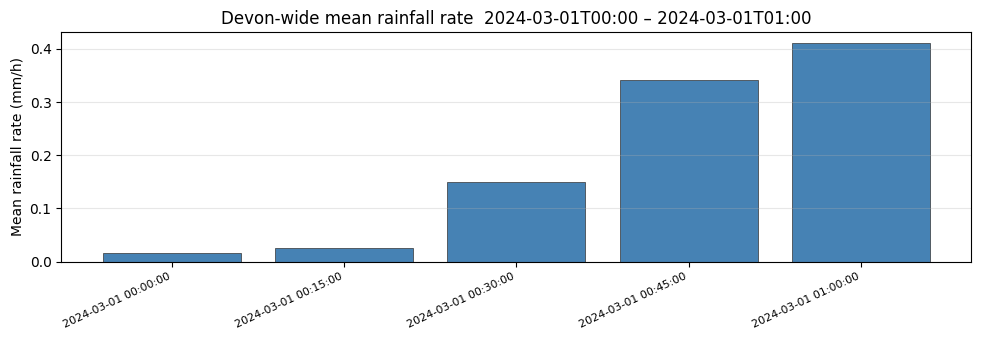

In [6]:
# ── Time series: Devon-wide mean rainfall at each 15-minute timestep ───────
mean_per_step = devon_da.mean(dim=['y', 'x'])   # shape (time,)

timestamps = [str(t)[:19] for t in mean_per_step.time.values]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(
    range(len(timestamps)),
    mean_per_step.values,
    color='steelblue',
    edgecolor='#333333',
    linewidth=0.5,
)
ax.set_xticks(range(len(timestamps)))
ax.set_xticklabels(timestamps, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Mean rainfall rate (mm/h)')
ax.set_title(
    f'Devon-wide mean rainfall rate  {START_DT} – {END_DT}',
    fontsize=12,
)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 3 — Interactive Devon rainfall map

The map below shows the rainfall rate (mm/h) across Devon for the
timestep with the **highest Devon-wide mean**, rendered as a
semi-transparent raster overlay on a CartoDB positron basemap.

Pixels outside the Devon county boundary are transparent (masked to
`NaN` by `get_rainfall_for_polygon`).  **Use the layer control**
(top-right) to toggle layers on or off.


Peak timestep : 2024-03-01 01:00:00  (mean 0.4105 mm/h)



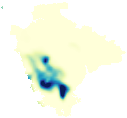

In [7]:
# Timestep with the highest Devon-wide mean rainfall
peak_idx  = int(mean_per_step.argmax())
peak_da   = devon_da.isel(time=peak_idx)
peak_time = str(devon_da.time.values[peak_idx])[:19]
peak_mean = float(mean_per_step.isel(time=peak_idx))
print(f'Peak timestep : {peak_time}  (mean {peak_mean:.4f} mm/h)')

# ── Build folium map ───────────────────────────────────────────────────────
m = folium.Map(
    location=DEVON_CENTRE,
    zoom_start=9,
    tiles=TILES,
    scroll_wheel_zoom=False,
    height=620,
)

# Devon boundary
folium.GeoJson(
    devon_gdf.__geo_interface__,
    name='Devon boundary',
    style_function=lambda _: {
        'color':       '#2c6e8a',
        'fillColor':   'none',
        'fillOpacity': 0,
        'weight':      2.5,
    },
).add_to(m)

# Rainfall raster
_make_rain_overlay(
    peak_da,
    label=f'Rainfall {peak_time}',
).add_to(m)

# Colour-bar legend
vmax_lg = float(np.nanpercentile(peak_da.values, 99))
m.get_root().html.add_child(folium.Element(_rain_legend_html(vmax_lg)))

folium.LayerControl(collapsed=False).add_to(m)
m


## 4 — Per-catchment rainfall

For each of the 10 sample sites with a delineated catchment polygon we
call `get_rainfall_for_polygon` with the **same `DOWNLOAD_DIR`** used
above.  The function finds the already-downloaded NetCDF files, regrids
them to the catchment's bounding box at 1 km resolution, and masks to
the polygon boundary — no additional network traffic.

> **Tip:** very small catchments (< 5 km²) will have only a handful of
> 1 km grid pixels.  Decrease `RES_M` to `500` for finer coverage.


In [8]:
catchment_records = []

for sample in ds:
    if not sample.has_catchment:
        continue

    poly = sample.catchment   # Shapely Polygon in WGS 84

    try:
        t0 = _time.perf_counter()
        catch_da = get_rainfall_for_polygon(
            poly,
            start=START_DT,
            end=END_DT,
            download_dir=DOWNLOAD_DIR,   # reuse cached files — no re-download
            res=RES_M,
        )
        elapsed = _time.perf_counter() - t0

        mean_time = catch_da.mean(dim=['y', 'x'])     # mean over space per timestep
        mean_mm_h = float(mean_time.mean())           # overall mean
        peak_mm_h = float(catch_da.max())
        n_pixels  = int(np.sum(~np.isnan(catch_da.isel(time=0).values)))

        catchment_records.append({
            'notation':       sample.notation,
            'site_name':      sample.site_name,
            'area_km2':       round(sample.catchment_area_km2() or 0.0, 3),
            'n_pixels':       n_pixels,
            'mean_rain_mm_h': round(mean_mm_h, 5),
            'peak_rain_mm_h': round(peak_mm_h, 5),
        })
        print(
            f'  [{sample.notation}]  '
            f'mean={mean_mm_h:.5f} mm/h  '
            f'pixels={n_pixels}  '
            f'({elapsed:.1f} s)'
        )

    except Exception as exc:
        print(f'  [{sample.notation}]  ERROR: {exc}')

catch_df = (
    pd.DataFrame(catchment_records)
    .sort_values('mean_rain_mm_h', ascending=False)
    .reset_index(drop=True)
)
print(f'\nProcessed {len(catch_df)} catchment(s).')


2026-03-23 15:46:19,898 - eoflow.rainfall - INFO - get_rainfall_for_polygon
2026-03-23 15:46:19,899 - eoflow.rainfall - INFO -   Polygon BNG bounds : 308748, 87344 → 310299, 88702
2026-03-23 15:46:19,899 - eoflow.rainfall - INFO -   Extraction extent  : x=[308000, 312000]  y=[87000, 90000]  res=1000 m
2026-03-23 15:46:19,899 - eoflow.rainfall - INFO -   Time range         : 2024-03-01T00:00:00+00:00 → 2024-03-01T01:00:00+00:00
2026-03-23 15:46:19,900 - eoflow.rainfall - INFO - Downloading rainfall NetCDF files ...
2026-03-23 15:46:19,900 - eoflow.rainfall - INFO - Met Office UKV rainfall downloader
2026-03-23 15:46:19,901 - eoflow.rainfall - INFO -   Start   : 2024-03-01T00:00:00+00:00
2026-03-23 15:46:19,901 - eoflow.rainfall - INFO -   End     : 2024-03-01T01:00:00+00:00
2026-03-23 15:46:19,902 - eoflow.rainfall - INFO -   Output  : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/rainfall_cache
2026-03-23 15:46:19,902 - eoflow.rainfall - INFO -   Workers : 4
2026-03-23 15:46

In [9]:
# ── Results table ──────────────────────────────────────────────────────────
display_cols = [
    'notation', 'site_name', 'area_km2',
    'n_pixels', 'mean_rain_mm_h', 'peak_rain_mm_h',
]
catch_df[display_cols]


,notation,site_name,area_km2,n_pixels,mean_rain_mm_h,peak_rain_mm_h
0,SW-70720104,RIVER DART AT TOTNES WEIR,281.128,280,0.87150,6.57507
1,SW-70826005,RIVER AVON AT HATCH,102.955,102,0.44745,5.80378
2,SW-70620154,RIVER TEIGN AT PRESTON,106.654,105,0.16546,3.52711
3,SW-70920104,RIVER ERME AT SEQUER'S BRIDGE,1.234,1,0.03703,0.18513
4,SW-70540110,RIVER EXE AT TREWS WEIR EXETER,836.913,846,0.01878,3.80728
5,SW-70631918,KENNICK STREAM AT TOTTIFORD RESERVOIR SURFACE,4.931,6,0.00760,0.06558
6,SW-70540224,RIVER EXE AT THORVERTON GAUGING STATION,271.882,275,0.00044,0.12902
7,SW-70420116,RIVER OTTER AT DOTTON MILL,0.821,1,0.00000,0.00000
8,SW-72920121,RIVER TORRIDGE AT BEAM BRIDGE,3.890,3,0.00000,0.00000
9,SW-73020127,RIVER TAW AT CHAPELTON FOOTBRIDGE,1.071,0,NaN,NaN


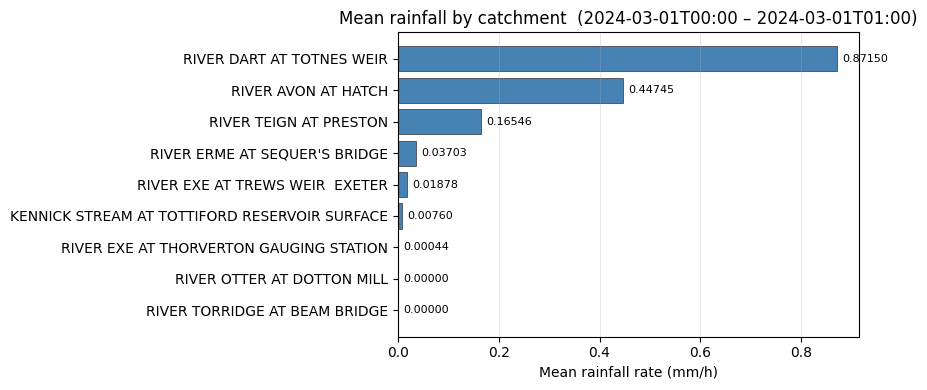

In [10]:
# ── Bar chart: mean rainfall by catchment ──────────────────────────────────
if len(catch_df) == 0:
    print('No catchment data to plot.')
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(
        catch_df['site_name'],
        catch_df['mean_rain_mm_h'],
        color='steelblue',
        edgecolor='#333333',
        linewidth=0.5,
    )
    offset = max(catch_df['mean_rain_mm_h']) * 0.012
    for bar, val in zip(bars, catch_df['mean_rain_mm_h']):
        ax.text(
            val + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.5f}',
            va='center',
            fontsize=8,
        )
    ax.set_xlabel('Mean rainfall rate (mm/h)')
    ax.set_title(
        f'Mean rainfall by catchment  ({START_DT} – {END_DT})',
        fontsize=12,
    )
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 5 — Devon overview map — rainfall + catchments

The interactive map below combines:

* The **Devon-wide rainfall raster** (peak timestep, 50 % opacity).
* The **Devon county boundary** (blue outline).
* Each **catchment polygon** coloured by its mean rainfall rate
  (yellow → blue colour ramp) with a click-to-open pop-up showing
  site notation, name, area, pixel count, and rainfall statistics.

Use the layer control (top-right) to toggle individual layers.



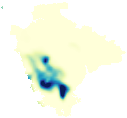

In [11]:
# ── Per-catchment colour lookup via matplotlib (avoids branca NaN issues) ──
import matplotlib.colors as _mcolors

_rn_valid = catch_df['mean_rain_mm_h'].dropna()
_rn_max   = float(_rn_valid.max()) if len(_rn_valid) else 0.0
_rn_max   = max(_rn_max, 1e-4)        # guarantee non-zero range
_norm_catch = plt.Normalize(vmin=0.0, vmax=_rn_max)
_cmap_catch = plt.get_cmap(RAIN_CMAP)

def _poly_fill(val):
    """Map a (possibly NaN) mean-rainfall value to a hex colour string."""
    v = float(val) if (val == val) else 0.0   # replace NaN with 0
    return _mcolors.to_hex(_cmap_catch(_norm_catch(max(0.0, v))))

# Branca colormap kept ONLY for the legend caption on the map;
# we never call catch_cm_legend(x) — that avoids the NaN/threshold bug.
catch_cm_legend = branca_cm.LinearColormap(
    colors=['#ffffcc', '#41b6c4', '#225ea8'],
    vmin=0.0,
    vmax=_rn_max,
    caption='Mean rainfall rate (mm/h)',
)

# ── Folium map ─────────────────────────────────────────────────────────────
m2 = folium.Map(
    location=DEVON_CENTRE,
    zoom_start=9,
    tiles=TILES,
    scroll_wheel_zoom=False,
    height=680,
)

# Devon boundary
folium.GeoJson(
    devon_gdf.__geo_interface__,
    name='Devon boundary',
    style_function=lambda _: {
        'color':       '#2c6e8a',
        'fillColor':   'none',
        'fillOpacity': 0,
        'weight':      2.0,
    },
).add_to(m2)

# Devon rainfall raster (50 % transparent)
if devon_da.sizes['time'] > 0:
    _make_rain_overlay(
        devon_da.isel(time=peak_idx),
        alpha=0.50,
        label=f'Devon rainfall {peak_time}',
    ).add_to(m2)

# Catchment polygons coloured by mean rainfall
if len(catch_df) > 0:
    catch_layer = folium.FeatureGroup(name='Catchments (mean rainfall)')

    for _, row in catch_df.iterrows():
        matches = [
            s for s in ds
            if s.notation == row['notation'] and s.has_catchment
        ]
        if not matches:
            continue
        sample   = matches[0]
        poly_geo = sample.catchment.__geo_interface__
        fill_col = _poly_fill(row['mean_rain_mm_h'])

        # Build popup text (avoid nested quotes)
        notation = row['notation']
        site     = row['site_name']
        area     = row['area_km2']
        npix     = row['n_pixels']
        mean_r   = row['mean_rain_mm_h']
        peak_r   = row['peak_rain_mm_h']
        popup_html = (
            '<b>' + notation + '</b><br>'
            + site + '<br>'
            + 'Area: {:.3f} km2<br>'.format(area)
            + 'Pixels: {}<br>'.format(npix)
            + 'Mean rain: {:.5f} mm/h<br>'.format(mean_r)
            + 'Peak rain: {:.5f} mm/h'.format(peak_r)
        )

        folium.GeoJson(
            {'type': 'Feature', 'geometry': poly_geo, 'properties': {}},
            style_function=lambda _, c=fill_col: {
                'fillColor':   c,
                'color':       '#333333',
                'weight':      1.5,
                'fillOpacity': 0.75,
            },
            tooltip=site,
            popup=folium.Popup(popup_html, max_width=290),
        ).add_to(catch_layer)

    catch_layer.add_to(m2)
    catch_cm_legend.add_to(m2)

# Rainfall intensity legend
vmax_lg2 = float(np.nanpercentile(devon_da.values, 99))
m2.get_root().html.add_child(folium.Element(_rain_legend_html(vmax_lg2)))

folium.LayerControl(collapsed=False).add_to(m2)
m2


In [ ]:
m2.show_in_browser()

Your map should have been opened in your browser automatically.
Press ctrl+c to return.


## 6 — Summary

| | |
|---|---|
| **Data source** | Met Office UKV 2 km deterministic NWP model via AWS Open Data S3 |
| **Coverage** | United Kingdom |
| **Temporal resolution** | 15-minute valid-time steps |
| **Native spatial resolution** | 2 km |
| **Output resolution (this notebook)** | 1 km (bilinear resampling) |
| **Output CRS** | EPSG:27700 (British National Grid) |
| **Units** | mm/h |

### Key function

```python
from eoflow.rainfall import get_rainfall_for_polygon

da = get_rainfall_for_polygon(
    polygon,                       # Shapely Polygon/MultiPolygon in WGS 84
    start='2024-03-01T00:00',
    end  ='2024-03-01T01:00',
    download_dir='./rainfall_cache',
    res=1_000,                     # metres — decrease for finer output
)
# da is an xarray.DataArray with dims (time, y, x) in EPSG:27700
# Values in mm/h; NaN where the pixel centre lies outside the polygon
```

### Further exploration

* Set `RES_M = 500` (or `250`) for denser output grids on small catchments
  (bilinear interpolation from the 2 km native data).
* Extend `END_DT` to cover multi-hour storm events.
* Combine with `eoflow.soil.soil_coverage` to correlate peak rainfall with
  runoff-risk soil-structure groups.
* Use `run_hour=0` to pin queries to the Met Office midnight model run.
